# Difference Finite Scheme of Diffusive Equation derived from Lattice Boltzmann

## MRT Lattice Boltzmann equation for Diffusive Equation

To describe convective-diffusive problems, the MRT lattice Boltzmann formulation is described by:

$$
f_i( x_{\alpha} + e_{i,\alpha} \delta t, t+\delta t) = f_i(x_{\alpha}, t)  - (\textbf{M}^{-1}\textbf{S}\textbf{M})_{ik}\left( f_{k} - f_{k}^{eq}  \right), 
$$(MRT-Herm-LB-conv-df-Eq)

where $\textbf{M}$ is matrix of moments, $\textbf{S}$ is the diagonal matrix of relaxation times, and $\textbf{M}^{-1}$ is the inverse matrix of $\textbf{M}$. Considering the problem description in a lattice D1Q3, we have:

$$
\textbf{M} =\begin{pmatrix} 1 \\ e_{i,x} \\ e_{i,x}^{2}-c_{s}^{2} \end{pmatrix} =\begin{pmatrix} 1 & 1 & 1 \\ 0 & 1   & -1 \\ -1/3  & 2/3 & 2/3 \end{pmatrix},  \qquad \qquad  \textbf{S} = \begin{pmatrix} s_0 & 0   & 0 \\ 0   & s_1 & 0 \\ 0   & 0   & s_2 \end{pmatrix},  \qquad \qquad \textbf{M}^{-1}=\begin{pmatrix}1-c_{s}^{2} & 0 & -1 \\ \dfrac{c_{s}^{2}}{2} & \dfrac{1}{2} & \dfrac{1}{2} \\ \dfrac{c_{s}^{2}}{2} & -\dfrac{1}{2} & \dfrac{1}{2} \end{pmatrix}.
$$

The equilibrium distribution function is defined by

$$
f^{eq}_{i} = w_{i} \phi.
$$

In [1]:
import warnings
warnings.filterwarnings("ignore")
from pylab import *
from __future__ import division
from sympy import *
import numpy as np
from sympy import S, collect, expand, factor, Wild
from sympy import fraction, Rational, Symbol
from sympy import symbols, sqrt, Rational
import sympy as sp
from IPython.display import display, Math, Latex
#-------------------------------------------------Símbolos----------------------------------------------
omega, phi = symbols('omega, \\phi')
wi, w0, w1, cx, cy, cs = symbols('w_{i} w_{0} w_{1} c_{x} c_{y} c_{s}')
#-------------------------------------------------Funções----------------------------------------------
feq = Function('feq')(wi, cx, cy)
#----------------------------------------------Lattice-D2Q9---Variáveis----------------------------------------------
wi=np.array([w0,(1-w0)/2,(1-w0)/2])
cx=np.array([0,1,-1])
cs2=(1-w0)
#-------------------------------------------------Calc.Func------------------------------------------------
feq=wi*phi

In [2]:
a0=simplify(sum(feq))
ax=simplify(sum(feq*cx))
axx=simplify(sum(feq*cx*cx))
axxx=simplify(sum(feq*cx*cx*cx))
display(Math(r"\underbrace{\sum_{i=0} f_{i}^{eq} =\sum_{i=0} f_{i} }_{\textrm{Zero-Order Moment}} =" +  sp.latex(a0) 
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq}e_{i,x} }_{\textrm{x-First-Order Moment}} =" +  sp.latex(ax)
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} e_{i,x}e_{i,x} }_{\textrm{xx-Second-Order Moment}} =" +  sp.latex(axx)
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} e_{i,x}e_{i,x}e_{i,x} }_{\textrm{xxx-Third-Order Moment}} =" +  sp.latex(axxx) ))

aH0=simplify(sum(feq))
aHx=simplify(sum(feq*cx))
aHxx=simplify(sum(feq*(cx*cx-cs2)))
aHxxx=simplify(sum(feq*(cx*cx-3*cs2)*cx))
display(Math(r"\underbrace{\sum_{i=0} f_{i}^{eq} =\sum_{i=0} f_{i} }_{\textrm{Zero-Order Hermite Moment}} =" +  sp.latex(aH0) 
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq}e_{i,x} }_{\textrm{x-First-Order Hermite Moment}} =" +  sp.latex(aHx)
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} \left(e_{i,x}e_{i,x} - c_{s}^{2}\right) }_{\textrm{xx-Second-Order Hermite Moment}} =" +  sp.latex(aHxx)
            +r",\quad \quad \underbrace{\sum_{i=0} f_{i}^{eq} \left(e_{i,x}e_{i,x} - 3c_{s}^{2}\right) e_{i,x} }_{\textrm{xxx-Third-Order Hermite Moment}} =" +  sp.latex(aHxxx) ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [3]:
import warnings
warnings.filterwarnings("ignore")
from pylab import *
from sympy import *
import numpy as np
s0, s1, s2 = symbols(['s_0','s_1','s_2'])
Tc0, Tc1, Tc2= symbols([r'T_{\Delta_{x}}^{c_{0}}','T_{\Delta_{x}}^{c_{1}}','T_{\Delta_{x}}^{c_{2}}'])
I=eye(3)
Tc = Matrix([I[0,:]*Tc0,I[1,:]*Tc1,I[2,:]*Tc2])
SM=Matrix([I[0,:]*s0,I[1,:]*s1,I[2,:]*s2])
feqM=Matrix([feq[0],feq[1],feq[2]])
m0=np.array([1,1,1])
m1=cx
m2=cx*cx - cs**2
M=np.array([m0,m1,m2])
MM=Matrix([m0,m1,m2])
MMinv=MM.inv()

In [4]:
TM=sp.simplify(MM*Tc*MMinv)
P=sp.simplify(TM*(I-SM))
Q=sp.simplify(TM*SM)

display(Math(r"\textbf{T} =" +  sp.latex(TM) +"," ))
display(Math(r"\textbf{P} =" +  sp.latex(P) +"," ))
display(Math(r"\textbf{Q} =" +  sp.latex(Q) +"." ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [5]:
from sympy import Matrix, symbols
X = symbols('X')
cp = P.charpoly(X)
# cp.as_expr() 
gamma3=Tc0
gamma2=sp.collect(cp.all_coeffs()[1],[s2,s1,s0])
gamma1=sp.simplify(sp.collect(cp.all_coeffs()[2],[s2*s1, s2, s1,s0]).subs(s0,0).subs(Tc1*Tc2,Tc0).subs(Tc0,1)).subs(2,2*Tc0).subs(1,Tc0)
gamma0=sp.factor(sp.collect(cp.all_coeffs()[3],[s2*s1, s2, s1,s0]).subs(s0,0).subs(Tc1*Tc2,Tc0).subs(Tc0,1))*Tc0

display(Math(r"\gamma_{3} =" +  sp.latex(gamma3) +"," ))
display(Math(r"\gamma_{2} =" +  sp.latex(gamma2) +"," ))
display(Math(r"\gamma_{1} =" +  sp.latex(gamma1) +"," ))
display(Math(r"\gamma_{0} =" +  sp.latex(gamma0) +"." ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [6]:
import sympy as sp
# ---------------- indices / parameters ----------------
q = sp.Symbol('q', integer=True, positive=True)
n, l = sp.symbols('n l', integer=True, nonnegative=True)
m1s = sp.Symbol('m^{t+1}_{k,x}')
m0s = sp.Symbol('m^{t}_{k,x}')
mm1s = sp.Symbol('m^{t-1}_{k,x}')
mm2s = sp.Symbol('m^{t-2}_{k,x}')
meq0s = sp.Symbol('m^{eq,t}_{k,x}')
meqm1s = sp.Symbol('m^{eq,t-1}_{k,x}')
meqm2s = sp.Symbol('m^{eq,t-2}_{k,x}')

# gamma_j as an indexed coefficient sequence
gammas = sp.IndexedBase('gamma')   # gamma[j] means γ_j

# Abstract time-shifted moments:
# m(s)    := m_{k,x}^{t+s}
# meq(s)  := m_{k,x}^{eq, t+s}
ms   = sp.Function('m')
meqs = sp.Function('m_eq')

# Operators/matrices (leave as Symbols unless you need matrix algebra)
Ps = sp.Symbol('P')
Qs = sp.Symbol('Q')

# ---------------- build the equation ----------------
lhs = gammas[q] * ms(1)  # γ_q * m^{t+1}

rhs1 = -sp.summation(gammas[n] * ms(1 - q + n), (n, 0, q-1))

inner = sp.summation(gammas[q + l - n] * Ps**l, (l, 0, n))
rhs2  = sp.summation(inner * Qs * meqs(-n), (n, 0, q-1))

# eq = sp.Eq(lhs, rhs1 + rhs2)
eq = rhs1 + rhs2
eq1 = lhs.subs({ms(1):m1s,gammas[q]:gammas[3]})

# ---------------- expand for a concrete q ----------------
# SymPy can only 'doit' finite sums once q is a number.
q_val = 3  # <-- change to 2,3,4,... as needed
eq_expanded = sp.expand(eq.subs(q, q_val).doit())

# print(f"\nExpanded for q={q_val}:")
# display(eq_expanded)

eqsubs=eq_expanded.subs({ms(1):m1s,ms(0):m0s,ms(-1):mm1s,ms(-2):mm2s,meqs(0):meq0s,meqs(0):meq0s,meqs(-1):meqm1s,meqs(-2):meqm2s})
sp.Eq(eq1, eqsubs)

Eq(m^{t+1}_{k,x}*gamma[3], P**2*Q*m^{eq,t-2}_{k,x}*gamma[3] + P*Q*m^{eq,t-1}_{k,x}*gamma[3] + P*Q*m^{eq,t-2}_{k,x}*gamma[2] + Q*m^{eq,t-1}_{k,x}*gamma[2] + Q*m^{eq,t-2}_{k,x}*gamma[1] + Q*m^{eq,t}_{k,x}*gamma[3] - m^{t-1}_{k,x}*gamma[1] - m^{t-2}_{k,x}*gamma[0] - m^{t}_{k,x}*gamma[2])

In [7]:
import sympy as sp
# ---------------- indices / parameters ----------------
meq0k11s = sp.Symbol('m^{eq,t+1}_{0,x}')
meq0k0s = sp.Symbol('m^{eq,t}_{0,x}')
meq1k0s = sp.Symbol('m^{eq,t}_{1,x}')
meq2k0s = sp.Symbol('m^{eq,t}_{2,x}')
MeqM0s=Matrix([meq0k0s,meq1k0s,meq2k0s])
meq0k1s = sp.Symbol('m^{eq,t-1}_{0,x}')
meq1k1s = sp.Symbol('m^{eq,t-1}_{1,x}')
meq2k1s = sp.Symbol('m^{eq,t-1}_{2,x}')
MeqM1s=Matrix([meq0k1s,meq1k1s,meq2k1s])
meq0k2s = sp.Symbol('m^{eq,t-2}_{0,x}')
meq1k2s = sp.Symbol('m^{eq,t-2}_{1,x}')
meq2k2s = sp.Symbol('m^{eq,t-2}_{2,x}')
MeqM2s=Matrix([meq0k2s,meq1k2s,meq2k2s])
m0k11s = sp.Symbol('m^{t+1}_{0,x}')
m0k0s = sp.Symbol('m^{t}_{0,x}')
m0k1s = sp.Symbol('m^{t-1}_{0,x}')
m0k2s = sp.Symbol('m^{t-2}_{0,x}')
m1k0s = sp.Symbol('m^{t}_{1,x}')
m1k1s = sp.Symbol('m^{t-1}_{1,x}')
m1k2s = sp.Symbol('m^{t-2}_{1,x}')

In [8]:
termmeqm1=collect(simplify(expand(Q*MeqM1s*gamma2 + P*Q*MeqM1s))[0].subs(Tc0*Tc1,Tc1).subs(Tc0*Tc2,Tc2).subs(Tc1*Tc2,Tc0).subs(s0,0),[meq0k1s,meq1k1s,meq2k1s])
termmeqm1
display(Math(r"\left[ P Q m^{eq,t-1}_{k,x} \gamma_{3} \right]_{k=0} + \left[ Q m^{eq,t-1}_{k,x} \gamma_{2} \right]_{k=0} =" +  sp.latex(termmeqm1) +"," ))

<IPython.core.display.Math object>

In [9]:
# termmeqm2 = expand((P*Q)*MeqMs*gamma2 + Q*MeqMs*gamma1)[0]
termmeqm2 = expand( ((P*P)*Q)*MeqM2s*gamma3 + (P*Q)*MeqM2s*gamma2 + Q*MeqM2s*gamma1)[0].subs(Tc1*Tc2,Tc0).subs(Tc0,1).subs(s0,0)
display(Math(r"\left[ P^{2} Q m^{eq,t-2}_{k,x} \gamma_{3} \right]_{k=0} + \left[ PQ m^{eq,t-2}_{k,x} \gamma_{2} \right]_{k=0} + \left[ Q m^{eq,t-2}_{k,x} \gamma_{1} \right]_{k=0} =" +  sp.latex(termmeqm2) +"," ))

<IPython.core.display.Math object>

In [10]:
termmeqm3 = (Q*MeqM0s)[0].subs(s0,0)
# sp.Eq(Qs*meq0s*gammas[3], termmeqm3)
display(Math(r"\left[Q m^{eq,t}_{k,x} \gamma_{3} \right]_{k=0} =" +  sp.latex(termmeqm3) +"." ))

<IPython.core.display.Math object>

In [11]:
eqsubs2=(eqsubs.subs({meqm2s:0,Ps*Qs*meqm1s*gammas[3] + Qs*meqm1s*gammas[2]:termmeqm1,Qs*meq0s*gammas[3]:termmeqm3})
        .subs({m0s:m0k0s,mm1s:m0k1s,mm2s:m0k2s}).subs({gammas[3]:gamma3,gammas[2]:gamma2,gammas[1]:gamma1,gammas[0]:gamma0}).subs({s0:0})
        )
sp.Eq(eq1.subs({m1s:m0k11s,gammas[3]:gamma3}), eqsubs2)

Eq(T_{\Delta_{x}}^{c_{0}}*m^{t+1}_{0,x}, T_{\Delta_{x}}^{c_{0}}*m^{t-2}_{0,x}*(s_1 - 1)*(s_2 - 1) + m^{eq,t-1}_{1,x}*(T_{\Delta_{x}}^{c_{1}}*s_1*s_2/2 - T_{\Delta_{x}}^{c_{1}}*s_1/2 - T_{\Delta_{x}}^{c_{2}}*s_1*s_2/2 + T_{\Delta_{x}}^{c_{2}}*s_1/2) + m^{eq,t-1}_{2,x}*(T_{\Delta_{x}}^{c_{0}}*s_1*s_2 - T_{\Delta_{x}}^{c_{0}}*s_2 - T_{\Delta_{x}}^{c_{1}}*s_1*s_2/2 + T_{\Delta_{x}}^{c_{1}}*s_2/2 - T_{\Delta_{x}}^{c_{2}}*s_1*s_2/2 + T_{\Delta_{x}}^{c_{2}}*s_2/2) + m^{eq,t}_{1,x}*s_1*(T_{\Delta_{x}}^{c_{1}} - T_{\Delta_{x}}^{c_{2}})/2 + m^{eq,t}_{2,x}*s_2*(-2*T_{\Delta_{x}}^{c_{0}} + T_{\Delta_{x}}^{c_{1}} + T_{\Delta_{x}}^{c_{2}})/2 - m^{t-1}_{0,x}*(T_{\Delta_{x}}^{c_{0}} + T_{\Delta_{x}}^{c_{1}} + T_{\Delta_{x}}^{c_{2}} + s_1*s_2*(-2*T_{\Delta_{x}}^{c_{0}}*c_{s}**(2*T_{\Delta_{x}}^{c_{0}}) + 2*T_{\Delta_{x}}^{c_{0}} + T_{\Delta_{x}}^{c_{1}}*c_{s}**(2*T_{\Delta_{x}}^{c_{0}}) + T_{\Delta_{x}}^{c_{2}}*c_{s}**(2*T_{\Delta_{x}}^{c_{0}}))/2 - s_1*(2*T_{\Delta_{x}}^{c_{0}} + T_{\Delta_{x}}^{c_{1}

In [12]:
m0k0sdp1 = sp.Symbol('m^{t}_{0,x+1}')
m0k0sdm1 = sp.Symbol('m^{t}_{0,x-1}')
m1k0sdp1 = sp.Symbol('m^{t}_{1,x+1}')
m1k0sdm1 = sp.Symbol('m^{t}_{1,x-1}')
m0k1sdp1 = sp.Symbol('m^{t-1}_{0,x+1}')
m0k1sdm1 = sp.Symbol('m^{t-1}_{0,x-1}')
m1k1sdp1 = sp.Symbol('m^{t-1}_{1,x+1}')
m1k1sdm1 = sp.Symbol('m^{t-1}_{1,x-1}')

meq0k0sdp1 = sp.Symbol('m^{eq,t}_{0,x+1}')
meq0k0sdm1 = sp.Symbol('m^{eq,t}_{0,x-1}')
meq1k0sdp1 = sp.Symbol('m^{eq,t}_{1,x+1}')
meq1k0sdm1 = sp.Symbol('m^{eq,t}_{1,x-1}')
meq2k0sdp1 = sp.Symbol('m^{eq,t}_{2,x+1}')
meq2k0sdm1 = sp.Symbol('m^{eq,t}_{2,x-1}')

meq0k1sdp1 = sp.Symbol('m^{eq,t-1}_{0,x+1}')
meq0k1sdm1 = sp.Symbol('m^{eq,t-1}_{0,x-1}')
meq1k1sdp1 = sp.Symbol('m^{eq,t-1}_{1,x+1}')
meq1k1sdm1 = sp.Symbol('m^{eq,t-1}_{1,x-1}')
meq2k1sdp1 = sp.Symbol('m^{eq,t-1}_{2,x+1}')
meq2k1sdm1 = sp.Symbol('m^{eq,t-1}_{2,x-1}')

In [13]:
eqsubs3 = (collect(expand(eqsubs2).subs({Tc0:1})
                .subs({Tc2*m0k0s:m0k0sdp1,Tc1*m0k0s:m0k0sdm1})
                .subs({Tc2*m0k1s:m0k1sdp1,Tc1*m0k1s:m0k1sdm1})
                .subs({Tc2*m1k0s:m1k0sdp1,Tc1*m1k0s:m1k0sdm1})
                .subs({Tc2*m1k1s:m1k1sdp1,Tc1*m1k1s:m1k1sdm1})
                .subs({Tc2*meq0k0s:meq0k0sdp1,Tc1*meq0k0s:meq0k0sdm1})
                .subs({Tc2*meq1k0s:meq1k0sdp1,Tc1*meq1k0s:meq1k0sdm1})
                .subs({Tc2*meq2k0s:meq2k0sdp1,Tc1*meq2k0s:meq2k0sdm1})
                .subs({Tc2*meq0k1s:meq0k1sdp1,Tc1*meq0k1s:meq0k1sdm1})
                .subs({Tc2*meq1k1s:meq1k1sdp1,Tc1*meq1k1s:meq1k1sdm1})
                .subs({Tc2*meq2k1s:meq2k1sdp1,Tc1*meq2k1s:meq2k1sdm1})
                ,[m0k2s, m0k0sdp1,m0k0sdm1,m0k0s, m1k0sdp1,m1k0sdm1,m1k0s, m0k1sdm1,m0k1sdp1,m0k1s, m1k1sdm1,m1k1sdp1,m1k1s, 
                  meq0k0sdm1,meq0k0sdp1,meq0k0s, meq1k0sdm1,meq1k0sdp1,meq1k0s, meq2k0sdm1,meq2k0sdp1,meq2k0s, meq0k1sdm1,meq0k1sdp1,meq0k1s, meq1k1sdm1,meq1k1sdp1,meq1k1s, meq2k1sdm1,meq2k1sdp1,meq2k1s])
          )
sp.Eq(eq1.subs({m1s:m0k11s,gammas[3]:1}), eqsubs3)

Eq(m^{t+1}_{0,x}, m^{eq,t-1}_{1,x+1}*(-s_1*s_2/2 + s_1/2) + m^{eq,t-1}_{1,x-1}*(s_1*s_2/2 - s_1/2) + m^{eq,t-1}_{2,x+1}*(-s_1*s_2/2 + s_2/2) + m^{eq,t-1}_{2,x-1}*(-s_1*s_2/2 + s_2/2) + m^{eq,t-1}_{2,x}*(s_1*s_2 - s_2) - m^{eq,t}_{1,x+1}*s_1/2 + m^{eq,t}_{1,x-1}*s_1/2 + m^{eq,t}_{2,x+1}*s_2/2 + m^{eq,t}_{2,x-1}*s_2/2 - m^{eq,t}_{2,x}*s_2 + m^{t-1}_{0,x+1}*(-c_{s}**2*s_1*s_2/2 + c_{s}**2*s_2/2 + s_1/2 + s_2/2 - 1) + m^{t-1}_{0,x-1}*(-c_{s}**2*s_1*s_2/2 + c_{s}**2*s_2/2 + s_1/2 + s_2/2 - 1) + m^{t-1}_{0,x}*(c_{s}**2*s_1*s_2 - c_{s}**2*s_2 - s_1*s_2 + s_1 + s_2 - 1) + m^{t-2}_{0,x}*(s_1*s_2 - s_1 - s_2 + 1) + m^{t}_{0,x+1}*(c_{s}**2*s_2/2 - s_1/2 - s_2/2 + 1) + m^{t}_{0,x-1}*(c_{s}**2*s_2/2 - s_1/2 - s_2/2 + 1) + m^{t}_{0,x}*(-c_{s}**2*s_2 + 1))

In [14]:
u11s = sp.Symbol('\\phi^{t+1}_{x}')
u0s = sp.Symbol('\\phi^{t}_{x}')
u1s = sp.Symbol('\\phi^{t-1}_{x}')
u2s = sp.Symbol('\\phi^{t-2}_{x}')
u0sdp1 = sp.Symbol('\\phi^{t}_{x+1}')
u0sdm1 = sp.Symbol('\\phi^{t}_{x-1}')
u1sdp1 = sp.Symbol('\\phi^{t-1}_{x+1}')
u1sdm1 = sp.Symbol('\\phi^{t-1}_{x-1}')

In [15]:
eqsubs4 = collect(eqsubs3.subs({m0k0s:u0s,m0k1s:u1s,m0k2s:u2s,m0k0sdp1:u0sdp1,m0k0sdm1:u0sdm1,m0k1sdm1:u1sdm1,m0k1sdp1:u1sdp1})
          .subs({meq0k0s:u0s, meq0k0sdp1:u0sdp1,meq0k0sdm1:u0sdm1, meq0k1s:u1s, meq0k1sdp1:u1sdp1,meq0k1sdm1:u1sdm1})
          .subs({meq1k0s:0,meq1k0sdp1:0,meq1k0sdm1:0,meq1k1s:0,meq1k1sdp1:0,meq1k1sdm1:0})
          .subs({meq2k0sdp1:0,meq2k0sdm1:0,meq2k1sdp1:0,meq2k1sdm1:0})
          .subs({meq2k0s:0,meq2k1s:0}), [u0s,u0sdp1,u0sdm1, u1s,u1sdp1,u1sdm1] )
sp.Eq(eq1.subs({m1s:u11s,gammas[3]:1}), eqsubs4)

Eq(\phi^{t+1}_{x}, \phi^{t-1}_{x+1}*(-c_{s}**2*s_1*s_2/2 + c_{s}**2*s_2/2 + s_1/2 + s_2/2 - 1) + \phi^{t-1}_{x-1}*(-c_{s}**2*s_1*s_2/2 + c_{s}**2*s_2/2 + s_1/2 + s_2/2 - 1) + \phi^{t-1}_{x}*(c_{s}**2*s_1*s_2 - c_{s}**2*s_2 - s_1*s_2 + s_1 + s_2 - 1) + \phi^{t-2}_{x}*(s_1*s_2 - s_1 - s_2 + 1) + \phi^{t}_{x+1}*(c_{s}**2*s_2/2 - s_1/2 - s_2/2 + 1) + \phi^{t}_{x-1}*(c_{s}**2*s_2/2 - s_1/2 - s_2/2 + 1) + \phi^{t}_{x}*(-c_{s}**2*s_2 + 1))

In [16]:
alpha1s = sp.Symbol('\\alpha_{1}')
alpha1 = eqsubs4.coeff(u0s)
alpha2s = sp.Symbol('\\alpha_{2}')
alpha2 = eqsubs4.coeff(u0sdp1)
beta1s = sp.Symbol('\\beta_{1}')
beta1 = eqsubs4.coeff(u1s)
beta2s = sp.Symbol('\\beta_{2}')
beta2 = eqsubs4.coeff(u1sdp1)
gammass = sp.Symbol('\\gamma')
gamma = eqsubs4.coeff(u2s)

eqsubs5 = (eqsubs4.subs({beta2:beta2s,beta1:beta1s,alpha2:alpha2s,alpha1:alpha1s,gamma:gammass})
          )
sp.Eq(eq1.subs({m1s:u11s,gammas[3]:1}), eqsubs5)

Eq(\phi^{t+1}_{x}, \alpha_{1}*\phi^{t}_{x} + \alpha_{2}*\phi^{t}_{x+1} + \alpha_{2}*\phi^{t}_{x-1} + \beta_{1}*\phi^{t-1}_{x} + \beta_{2}*\phi^{t-1}_{x+1} + \beta_{2}*\phi^{t-1}_{x-1} + \gamma*\phi^{t-2}_{x})

In [17]:
display(Math(r"\alpha_{1} =" +  sp.latex(alpha1) +r",\qquad \alpha_{2}="+  sp.latex(alpha2) + r",\qquad\beta_{1}=" +  sp.latex(beta1) +r",\qquad \beta_{2}="+  sp.latex(beta2) ))
display(Math(r"\gamma="+  sp.latex(gamma) ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [18]:
import sympy as sp
# -----------------------------------------------------------------------------
# 1) Symbols (parameters and step sizes)
# -----------------------------------------------------------------------------
dx, dt = sp.symbols('Delta_x Delta_t', positive=True, real=True)
nu = sp.symbols('\\nu')

def d(name, nx=0, nt=0):
    n = nx + nt
    if n == 1:
        num = rf"\partial{{{name}}}"
    else:
        num = rf"\partial^{{{n}}}{{{name}}}"
    den = ""
    if nx:
        den += rf"\partial{{x^{{{nx}}}}}" if nx > 1 else r"\partial{x}"
    if nt:
        den += rf"\partial{{t^{{{nt}}}}}" if nt > 1 else r"\partial{t}"
    return sp.Symbol(rf"\frac{{{num}}}{{{den}}}")
# -------------------1st-Order-Terms----------------------
dphit = d(r"\phi", nt=1); dphix   = d(r"\phi", nx=1)
# -------------------2nd-Order-Terms----------------------
dphix2 = d(r"\phi", nx=2); dphixt = d(r"\phi", nx=1, nt=1); dphit2 = d(r"\phi", nt=2)
# -------------------3rd-Order-Terms----------------------
dphix3 = d(r"\phi", nx=3); dphix2t = d(r"\phi", nx=2, nt=1); dphixt2 = d(r"\phi", nx=1, nt=2); dphit3  = d(r"\phi", nt=3)
# -------------------4th-Order-Terms----------------------
dphix4 = d(r"\phi", nx=4); dphix3t = d(r"\phi", nx=3, nt=1); dphix2t2 = d(r"\phi", nx=2, nt=2); dphixt3 = d(r"\phi", nx=1, nt=3); dphit4 = d(r"\phi", nt=4)
# -------------------5th-Order-Terms----------------------
dphix5 = d(r"\phi", nx=5); dphix4t = d(r"\phi", nx=4, nt=1); dphix3t2 = d(r"\phi", nx=3, nt=2); dphix2t3 = d(r"\phi", nx=2, nt=3); dphixt4 = d(r"\phi", nx=1, nt=4); dphit5 = d(r"\phi", nt=5)
# -------------------5th-Order-Terms----------------------
dphix6 = d(r"\phi", nx=6); dphix5t = d(r"\phi", nx=5, nt=1); dphix4t2 = d(r"\phi", nx=4, nt=2); dphix3t3 = d(r"\phi", nx=3, nt=3); dphix2t4 = d(r"\phi", nx=2, nt=4); dphixt5 = d(r"\phi", nx=1, nt=5); dphit6 = d(r"\phi", nt=6)

# alpha1 = sp.simplify(1 - s1/2 - w0*s2/2)
# alpha2 = sp.simplify((w0-1)*s2 + 1)
# beta1  = sp.simplify(w0*s1*s2/2 - s1*s2/2 - w0*s2/2 + s1/2 +s2 -1)
# beta2  = sp.simplify(-w0*s1*s2 + w0*s2 + s1 - 1)
# gamma  = sp.simplify((s1-1)*(s2-1))
# -----------------------------------------------------------------------------
# 2) Continuous variables and field
# -----------------------------------------------------------------------------
x, t = sp.symbols('x t', real=True)
phi = sp.Function('phi')
# Shorthand for the base (continuous) field value at (x,t)
PHI = phi(x, t)

In [19]:
def taylor_phi(sx=0, st=0, order_x=6, order_t=6):
    expr = sp.S(0)
    # Keep all mixed terms up to the specified individual orders.
    for m in range(order_x + 1):
        for n in range(order_t + 1):
            # skip the (0,0) term? no, keep it.
            term = ( (sx*dx)**m * (st*dt)**n
                    / (sp.factorial(m)*sp.factorial(n))
                    * sp.diff(PHI, x, m, t, n) )
            expr += term
    return sp.expand(expr)

In [20]:
from IPython.display import display, Math
# phi_x^{t+1}, phi_x^{t}, phi_x^{t-1}, phi_x^{t-2}
phi_t_p1 = taylor_phi(sx=0,  st=+1, order_x=0, order_t=6)
display( Math(r"\phi_x^{t+1} = " + sp.latex(phi_t_p1)))
phi_t_0  = taylor_phi(sx=0,  st=0,  order_x=0, order_t=0)  # exactly phi(x,t)
display( Math(r"\phi_x^{t} = " + sp.latex(phi_t_0)))
phi_t_m1 = taylor_phi(sx=0,  st=-1, order_x=0, order_t=6)
display( Math(r"\phi_x^{t-1} = " + sp.latex(phi_t_m1)))
phi_t_m2 = taylor_phi(sx=0,  st=-2, order_x=0, order_t=6)
display( Math(r"\phi_x^{t-2} = " + sp.latex(phi_t_m2)))

# phi_{x±1}^{t}
phi_xm1_t0 = taylor_phi(sx=-1, st=0,  order_x=6, order_t=0)
display( Math(r"\phi_{x-1}^{t} = " + sp.latex(phi_xm1_t0)))
phi_xp1_t0 = taylor_phi(sx=+1, st=0,  order_x=6, order_t=0)
display( Math(r"\phi_{x+1}^{t} = " + sp.latex(phi_xp1_t0)))

# phi_{x±1}^{t-1}
phi_xm1_tm1 = taylor_phi(sx=-1, st=-1, order_x=6, order_t=6)
display( Math(r"\phi_{x-1}^{t-1} = " + sp.latex(phi_xm1_tm1)))
phi_xp1_tm1 = taylor_phi(sx=+1, st=-1, order_x=6, order_t=6)
display( Math(r"\phi_{x+1}^{t-1} = " + sp.latex(phi_xp1_tm1)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [21]:
# -----------------------------------------------------------------------------
# 5) Build the discrete equation (expanded) and move everything to one side
# -----------------------------------------------------------------------------
lhs = phi_t_p1

rhs = (alpha2*phi_xm1_t0 + alpha1*phi_t_0 + alpha2*phi_xp1_t0
       + beta2*phi_xm1_tm1 + beta1*phi_t_m1 + beta2*phi_xp1_tm1
       + gamma * phi_t_m2)

residual = sp.simplify(sp.expand(lhs - rhs))  # = 0 is the modified equation

In [22]:
max_dx=6
max_dt=3
max_total=6
expr = sp.expand(residual)
poly = sp.Poly(expr, dx, dt, domain='EX')  # keep symbolic coeffs
kept = sp.S(0)

for (px, pt), coeff in poly.terms():
    if (px <= max_dx) and (pt <= max_dt) and ((px + pt) <= max_total):
        kept += coeff * dx**px * dt**pt

In [23]:
term1 = sp.expand(kept).subs({
    # ------------------------------------------------6th order--------------------------------------------------------------------------------------------
    PHI.diff(x, 6): dphix6, PHI.diff(x, 5, t): dphix5t, PHI.diff(x, 4, t, 2): dphix4t2, PHI.diff(x, 3, t, 3): dphix3t3, PHI.diff(x, 2, t, 4): dphix2t4, PHI.diff(x, t, 5): dphixt5, PHI.diff(t, 6): dphit6,
    # ------------------------------------------------5th order--------------------------------------------------------------------------------------------
    PHI.diff(x, 5): dphix5, PHI.diff(x, 4, t): dphix4t, PHI.diff(x, 3, t, 2): dphix3t2, PHI.diff(x, 2, t, 3): dphix2t3, PHI.diff(x, t, 4): dphixt4, PHI.diff(t, 5): dphit5,
    # ------------------------------------------------4th order--------------------------------------------------------------------------------------------
    PHI.diff(x, 4):dphix4,PHI.diff(x, 3, t):dphix3t,PHI.diff(x, 2, t, 2):dphix2t2,PHI.diff(x, t, 3):dphixt3,PHI.diff(t, 4):dphit4,
    # ------------------------------------------------3rd order--------------------------------------------------------------------------------------------
    PHI.diff(x, 3):dphix3, PHI.diff(x, 2, t):dphix2t, PHI.diff(x, t, 2):dphixt2, PHI.diff(t, 3):dphit3,
    # ------------------------------------------------2nd order--------------------------------------------------------------------------------------------
    PHI.diff(x, 2):dphix2, PHI.diff(x, t):dphixt, PHI.diff(t, 2):dphit2,
    # ------------------------------------------------1st order--------------------------------------------------------------------------------------------
    PHI.diff(x):dphix, PHI.diff(t):dphit,
})
display(term1)

-Delta_t**3*Delta_x**2*\frac{\partial^{5}{\phi}}{\partial{x^{2}}\partial{t^{3}}}*c_{s}**2*s_1*s_2/12 + Delta_t**3*Delta_x**2*\frac{\partial^{5}{\phi}}{\partial{x^{2}}\partial{t^{3}}}*c_{s}**2*s_2/12 + Delta_t**3*Delta_x**2*\frac{\partial^{5}{\phi}}{\partial{x^{2}}\partial{t^{3}}}*s_1/12 + Delta_t**3*Delta_x**2*\frac{\partial^{5}{\phi}}{\partial{x^{2}}\partial{t^{3}}}*s_2/12 - Delta_t**3*Delta_x**2*\frac{\partial^{5}{\phi}}{\partial{x^{2}}\partial{t^{3}}}/6 + 7*Delta_t**3*\frac{\partial^{3}{\phi}}{\partial{t^{3}}}*s_1*s_2/6 - Delta_t**3*\frac{\partial^{3}{\phi}}{\partial{t^{3}}}*s_1 - Delta_t**3*\frac{\partial^{3}{\phi}}{\partial{t^{3}}}*s_2 + Delta_t**3*\frac{\partial^{3}{\phi}}{\partial{t^{3}}} + Delta_t**2*Delta_x**4*\frac{\partial^{6}{\phi}}{\partial{x^{4}}\partial{t^{2}}}*c_{s}**2*s_1*s_2/48 - Delta_t**2*Delta_x**4*\frac{\partial^{6}{\phi}}{\partial{x^{4}}\partial{t^{2}}}*c_{s}**2*s_2/48 - Delta_t**2*Delta_x**4*\frac{\partial^{6}{\phi}}{\partial{x^{4}}\partial{t^{2}}}*s_1/48 - Delt

In [24]:
term2 = sp.collect(sp.expand(-term1/(dt)/(s1*s2))+ dphit,[dphit,dphix,
                                                         dphix2*cs**2*dx*dx/dt,dphixt,dphit2*dt,
                                                         dphix2t*dx*dx,dphixt2,dphix3,dphit3*dt**2,
                                                         dphix2t2*dt*dx**2,dphix4*cs**2*dx**4/dt,
                                                         dphix4t*dx**4,dphix6*cs**2*dx**6/dt,
                                                        ]).subs(dphix4t2,0).subs(dphix2t3,0)
display( Math(r"\frac{\partial\phi}{\partial t}= " + sp.latex(term2)))

<IPython.core.display.Math object>

In [25]:
nut=dx*dx*cs**2*(-s1*s2/(2*s1*s2)+s2/(s1*s2))/dt
term3 = sp.collect(sp.expand(term2.subs(nut,nu)
                       .subs(dphit2,nut*nut*dphix4)
                       .subs(dphit3,nut*nut*nut*dphix6)
                       .subs(dphix2t,nut*dphix4)
                        .subs(dphix2t2,nut*nut*dphix6)
                        .subs(dphix4t,nut*dphix6)
                            ), [dphix2*dx**2/dt,dphix4*dx**4/dt,dphix6*dx**4/dt])
display( Math(r"\frac{\partial\phi}{\partial t}= " + sp.latex(term3)))

<IPython.core.display.Math object>

## Fouth-Order Term

In [26]:
dphix4_term3=sp.simplify(sp.factor(term3.coeff(dphix4)).subs(dt,dx*dx*cs**2*(-s1*s2/(2*s1*s2)+s2/(s1*s2))/nu))
display(dphix4_term3)
# display( Math(r"\frac{\partial\phi}{\partial t}= " + sp.latex(term3.subs(term3.coeff(dphix4),dphix4_term3))))

Delta_x**2*\nu*(-3*c_{s}**2*s_1**2*s_2 + 6*c_{s}**2*s_1**2 + 18*c_{s}**2*s_1*s_2 - 12*c_{s}**2*s_1 - 12*c_{s}**2*s_2 + s_1**2*s_2 - 6*s_1**2 - 6*s_1*s_2 + 12*s_1)/(12*s_1**2*s_2)

In [27]:
dphix4_term3_2=sp.factor(dphix4_term3.coeff(dx**2*nu/(12*s1**2*s2)))
display(dphix4_term3_2)

-3*c_{s}**2*s_1**2*s_2 + 6*c_{s}**2*s_1**2 + 18*c_{s}**2*s_1*s_2 - 12*c_{s}**2*s_1 - 12*c_{s}**2*s_2 + s_1**2*s_2 - 6*s_1**2 - 6*s_1*s_2 + 12*s_1

In [28]:
print(sp.pycode(dphix4_term3_2))

-3*c_{s}**2*s_1**2*s_2 + 6*c_{s}**2*s_1**2 + 18*c_{s}**2*s_1*s_2 - 12*c_{s}**2*s_1 - 12*c_{s}**2*s_2 + s_1**2*s_2 - 6*s_1**2 - 6*s_1*s_2 + 12*s_1


In [29]:
eq_sol_s2 = (-3*cs**2*s1**2*s2 + 6*cs**2*s1**2 + 18*cs**2*s1*s2 - 12*cs**2*s1 - 12*cs**2*s2 + s1**2*s2 - 6*s1**2 - 6*s1*s2 + 12*s1 )

sol_s2 = sp.solve(sp.Eq(eq_sol_s2, 0), s2)

display(sol_s2[0])
display(sp.simplify(sol_s2[0].subs(cs,1/sp.sqrt(3))))

6*s_1*(c_{s}**2*s_1 - 2*c_{s}**2 - s_1 + 2)/(3*c_{s}**2*s_1**2 - 18*c_{s}**2*s_1 + 12*c_{s}**2 - s_1**2 + 6*s_1)

s_1*(2 - s_1)

In [86]:
print(sp.pycode(sol_s2[0]))

6*s_1*(c_{s}**2*s_1 - 2*c_{s}**2 - s_1 + 2)/(3*c_{s}**2*s_1**2 - 18*c_{s}**2*s_1 + 12*c_{s}**2 - s_1**2 + 6*s_1)


## Sixth-Order Term

In [30]:
dphix6_term3=sp.simplify(sp.factor(term3.coeff(dphix6)).subs(dt,dx*dx*cs**2*(-s1*s2/(2*s1*s2)+s2/(s1*s2))/nu))
display(dphix6_term3)

Delta_x**4*\nu*(-60*c_{s}**4*s_1**3*s_2 + 90*c_{s}**4*s_1**3 + 375*c_{s}**4*s_1**2*s_2 - 450*c_{s}**4*s_1**2 - 690*c_{s}**4*s_1*s_2 + 720*c_{s}**4*s_1 + 360*c_{s}**4*s_2 - 360*c_{s}**4 + 15*c_{s}**2*s_1**3*s_2 - 45*c_{s}**2*s_1**3 - 60*c_{s}**2*s_1**2*s_2 + 180*c_{s}**2*s_1**2 + 90*c_{s}**2*s_1*s_2 - 180*c_{s}**2*s_1 + s_1**3*s_2 - 15*s_1**3 - 15*s_1**2*s_2 + 30*s_1**2)/(360*s_1**3*s_2)

In [31]:
# dphix6_term3_2=sp.factor(dphix6_term3.coeff(dx**4*nu/(360*s1**3*s2)))
dphix6_term3_2=sp.simplify(sp.factor(dphix6_term3.coeff(dx**4*nu)).subs(s2,sol_s2[0]))
display(dphix6_term3_2)

(-30*c_{s}**6*s_1**4 - 60*c_{s}**6*s_1**3 + 780*c_{s}**6*s_1**2 - 1440*c_{s}**6*s_1 + 720*c_{s}**6 + 75*c_{s}**4*s_1**4 - 240*c_{s}**4*s_1**3 + 240*c_{s}**4*s_1**2 - 28*c_{s}**2*s_1**4 + 60*c_{s}**2*s_1**3 - 60*c_{s}**2*s_1**2 + 3*s_1**4)/(720*s_1**4*(c_{s}**2 - 1))

In [32]:
dphix6_term3_3=sp.simplify(sp.factor(dphix6_term3_2.coeff(1/(720*s1**4*(cs**2-1)))) )
display(dphix6_term3_3)

-30*c_{s}**6*s_1**4 - 60*c_{s}**6*s_1**3 + 780*c_{s}**6*s_1**2 - 1440*c_{s}**6*s_1 + 720*c_{s}**6 + 75*c_{s}**4*s_1**4 - 240*c_{s}**4*s_1**3 + 240*c_{s}**4*s_1**2 - 28*c_{s}**2*s_1**4 + 60*c_{s}**2*s_1**3 - 60*c_{s}**2*s_1**2 + 3*s_1**4

In [33]:
print(sp.pycode(dphix6_term3_3))

-30*c_{s}**6*s_1**4 - 60*c_{s}**6*s_1**3 + 780*c_{s}**6*s_1**2 - 1440*c_{s}**6*s_1 + 720*c_{s}**6 + 75*c_{s}**4*s_1**4 - 240*c_{s}**4*s_1**3 + 240*c_{s}**4*s_1**2 - 28*c_{s}**2*s_1**4 + 60*c_{s}**2*s_1**3 - 60*c_{s}**2*s_1**2 + 3*s_1**4


In [128]:
import sympy as sp
import numpy as np

x, cs, s1 = sp.symbols('x cs s1')

eq_sol_cs = (-30*cs**6*s1**4 - 60*cs**6*s1**3 + 780*cs**6*s1**2 
             - 1440*cs**6*s1 + 720*cs**6 + 75*cs**4*s1**4 
             - 240*cs**4*s1**3 + 240*cs**4*s1**2 - 28*cs**2*s1**4 
             + 60*cs**2*s1**3 - 60*cs**2*s1**2 + 3*s1**4)

eq_x = sp.expand(eq_sol_cs.subs(cs**2, x))

poly = sp.Poly(eq_x, x)
coeffs_sym = poly.all_coeffs()          # highest degree first

s1_values = np.linspace(0.01, 0.92, 1000)
cs_values  = np.zeros(1000)
cs_values2 = np.zeros(1000)

for i, s1_val in enumerate(s1_values):
    s1_val = float(s1_val)
    # Numerically evaluate each coefficient at this s1
    coeffs_num = [complex(c.subs(s1, s1_val)) for c in coeffs_sym]

    roots_x = np.roots(coeffs_num)      # roots of polynomial in x = cs^2

    cs_roots = []
    for r in roots_x:
        if abs(r.imag) < 1e-12 and r.real > 0:
            cs_roots.append(np.sqrt(r.real))

    cs_roots.sort()

    if len(cs_roots) >= 1:
        cs_values[i] = cs_roots[0]
    if len(cs_roots) >= 2:
        cs_values2[i] = cs_roots[1]

(0.0, 2.0)

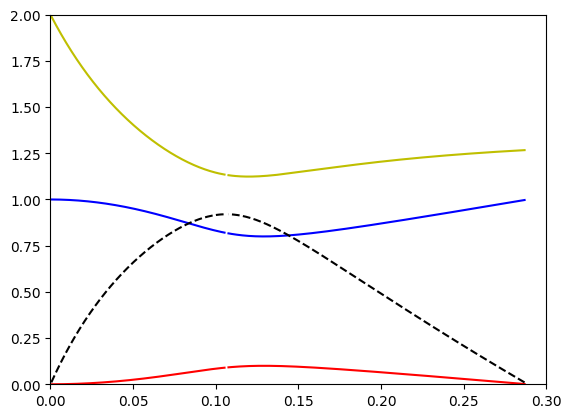

In [139]:
epss=(cs_values**2)*(1.0/s1_values-0.5)
w0_values=1.0-cs_values**2
w1_values=(1.0-w0_values)/2.0
s2_values=6.0*s1_values*(cs_values**2*s1_values - 2*cs_values**2 - s1_values + 2.0)/(3.0*cs_values**2*s1_values**2 - 18.0*cs_values**2*s1_values + 12.0*cs_values**2 - s1_values**2 + 6.0*s1_values)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
epss2=(cs_values2**2)*(1.0/s1_values-0.5)
w0_values2=1.0-cs_values2**2
w1_values2=(1.0-w0_values2)/2.0
s2_values2=6.0*s1_values*(cs_values2**2*s1_values - 2*cs_values2**2 - s1_values + 2.0)/(3.0*cs_values2**2*s1_values**2 - 18.0*cs_values2**2*s1_values + 12.0*cs_values2**2 - s1_values**2 + 6.0*s1_values)
# -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
plt.plot(epss,w0_values,'b-')
plt.plot(epss,w1_values,'r-')
plt.plot(epss,s1_values,'k--')
plt.plot(epss,s2_values,'y-')
plt.plot(epss2,w0_values2,'b-')
plt.plot(epss2,w1_values2,'r-')
plt.plot(epss2,s1_values,'k--')
plt.plot(epss2,s2_values2,'y-')
plt.xlim(0,0.3)
plt.ylim(0,2.0)

In [155]:
ni=995
print("cs= ",cs_values[ni])
print("w1= ",w1_values[ni])
print("w0= ",w0_values[ni])
print("s2= ",s2_values[ni])
print("s1= ",s1_values[ni])
print("epss= ",epss[ni])

cs=  0.4119435269680581
w1=  0.08484873470544163
w0=  0.8303025305891167
s2=  1.144274892526787
s1=  0.9163563563563564
epss=  0.10033846701337376


In [38]:
#****************************************Data-Analysis*********************************************
# ---------------- exact solution ----------------
def u_exact(x, t, A, k_w, phi, c, nu):
    return A * np.exp(-nu * k_w**2 * t) * np.sin(k_w * 2.0*np.pi * (x - c*t) + phi)
u_ana = np.empty(cases, dtype=object) # array field used to same data over time
xl = np.empty(cases, dtype=object) # array field used to same data over time
for i in range(cases):
    Nx=Nx0[i]  # Numerical Length
    dx = L / Nx # Grid size
    x = np.linspace(dtype(0.5)*dx,L-0.5*dx,Nx,dtype=dtype) # Numerical Domain
    ss1 = dtype(0.9118018018018018)
    tau1 = dtype(1.0)/ss1 # Relaxation parameters
    nue = (tau1 - dtype(0.5))*cs**2
    dt = nue*(dx * dx)/nu
    nt = int(np.ceil(t_end / dt))
    xl[i] = np.linspace(dtype(0.5)*dx,L-0.5*dx,Nx,dtype=dtype)
    print(f"dx={float(dx):.4e},\t "f"dt={float(dt):.4e}\t "f"nt={nt:d},\t "f"tn={float(dtype(nt)*dt):.10f}")
    print(f"c_lbm={float(ce):.6f},\t "f"tau1={float(tau1):.10f},\t "f"tau2={float(tau2):.10f}")
    print(f"s1={float(dtype(1.0)/tau1):.10f},\t "f"s2={float(dtype(1.0)/tau2):.10f},\t"
          f"w0={float(w0):.10f},\t "f"w1={float(w1):.10f},\t "f"cs={float(cs):.10f}")
    print(f"nt={nt:d},\t "f"nu={float(nu):.10f},\t "f"nue={float(nue):.10f}")
    print(f"---------------------------------------------------------------------------------------------")
    u_ana[i] = np.zeros((Nx0[i]), dtype="float64")
    u_ana[i] = u_exact(xl[i], nt*dt , A, k_w, phi, c, nu)
# -----------------Plot Results --------------------
plt.figure(figsize=(10,5))
colors = plt.cm.viridis(np.linspace(0, 1, cases))
for i in range(cases):
    plt.plot(xl[i], u_cases[i], "s", color=colors[i], lw=1, label=f"LBM  $Nx={Nx0[i]:.0f}$",fillstyle='none')
    plt.plot(xl[i], u_ana[i], color=colors[i], lw=1, label=f"Exact $t={t_end:.2f}$")

plt.xlabel("$x$",fontsize=16)
plt.ylabel("$u(x,t)$",fontsize=16)
plt.title("1D Convection-Diffusion: LBM vs Analytical Solution")
plt.grid(True, alpha=0.3)
plt.legend(ncol=5,fontsize=9,loc="center left",bbox_to_anchor=(0.0, 1.2))
plt.tight_layout()
plt.show()

dx=6.2832e-01,	 dt=1.5708e-01	 nt=77,	 tn=12.0951317163
c_lbm=0.000000,	 tau1=0.5401984953,	 tau2=0.1893578594
s1=1.8511713911,	 s2=5.2810060433
w0=-1.0730460868,	 w1=1.0365230434,	 cs=1.4398076562
nt=77,	 nue=0.0833333333
dx=3.1416e-01,	 dt=3.9270e-02	 nt=306,	 tn=12.0165919000
c_lbm=0.000000,	 tau1=0.5401984953,	 tau2=0.1893578594
s1=1.8511713911,	 s2=5.2810060433
w0=-1.0730460868,	 w1=1.0365230434,	 cs=1.4398076562
nt=306,	 nue=0.0833333333
dx=1.5708e-01,	 dt=9.8175e-03	 nt=1223,	 tn=12.0067744229
c_lbm=0.000000,	 tau1=0.5401984953,	 tau2=0.1893578594
s1=1.8511713911,	 s2=5.2810060433
w0=-1.0730460868,	 w1=1.0365230434,	 cs=1.4398076562
nt=1223,	 nue=0.0833333333


KeyboardInterrupt: 

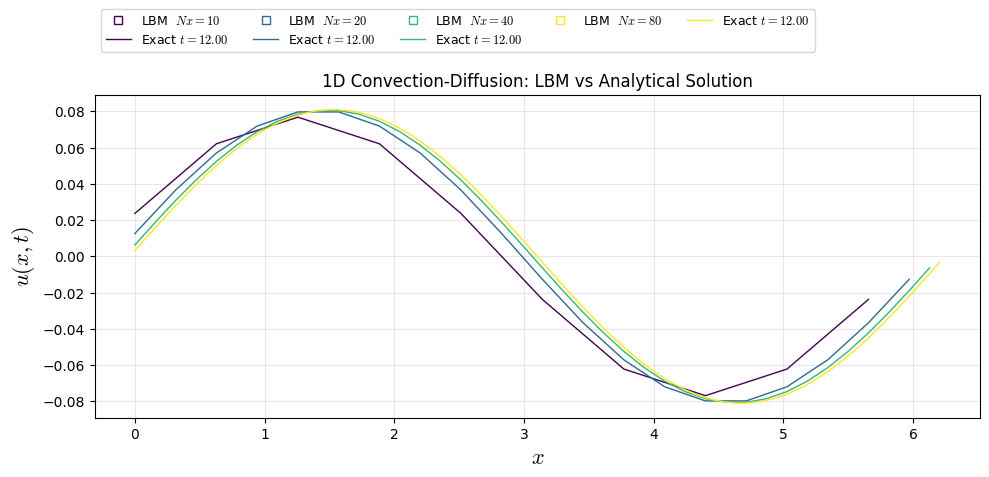

In [45]:
#****************************************Data-Analysis*********************************************
# ---------------- exact solution ----------------
def u_exact(x, t, A, k_w, phi, c, nu):
    return A * np.exp(-nu * k_w**2 * t) * np.sin(k_w * 2.0*np.pi * (x - c*t) + phi)
u_ana = np.empty(cases, dtype=object) # array field used to same data over time
xl = np.empty(cases, dtype=object) # array field used to same data over time
for i in range(cases):
    Nx=Nx0[i]  # Numerical Length
    dx = L / Nx # Grid size
    x = np.linspace(dtype(0.5)*dx,L-0.5*dx,Nx,dtype=dtype) # Numerical Domain
    ss1 = dtype(0.9118018018018018)
    tau1 = dtype(1.0)/ss1 # Relaxation parameters
    nue = (tau1 - dtype(0.5))*cs**2
    dt = nue*(dx * dx)/nu
    nt = int(np.ceil(t_end / dt))
    xl[i] = np.linspace(dtype(0.5)*dx,L-0.5*dx,Nx,dtype=dtype)
    print(f"dx={float(dx):.4e},\t "f"dt={float(dt):.4e}\t "f"nt={nt:d},\t "f"tn={float(dtype(nt)*dt):.10f}")
    print(f"c_lbm={float(ce):.6f},\t "f"tau1={float(tau1):.10f},\t "f"tau2={float(tau2):.10f}")
    print(f"s1={float(dtype(1.0)/tau1):.10f},\t "f"s2={float(dtype(1.0)/tau2):.10f},\t"
          f"w0={float(w0):.10f},\t "f"w1={float(w1):.10f},\t "f"cs={float(cs):.10f}")
    print(f"nt={nt:d},\t "f"nu={float(nu):.10f},\t "f"nue={float(nue):.10f}")
    print(f"---------------------------------------------------------------------------------------------")
    u_ana[i] = np.zeros((Nx0[i]), dtype="float64")
    u_ana[i] = u_exact(xl[i], nt*dt , A, k_w, phi, c, nu)
# -----------------Plot Results --------------------
plt.figure(figsize=(10,5))
colors = plt.cm.viridis(np.linspace(0, 1, cases))
for i in range(cases):
    plt.plot(xl[i], u_cases[i], "s", color=colors[i], lw=1, label=f"LBM  $Nx={Nx0[i]:.0f}$",fillstyle='none')
    plt.plot(xl[i], u_ana[i], color=colors[i], lw=1, label=f"Exact $t={t_end:.2f}$")

plt.xlabel("$x$",fontsize=16)
plt.ylabel("$u(x,t)$",fontsize=16)
plt.title("1D Convection-Diffusion: LBM vs Analytical Solution")
plt.grid(True, alpha=0.3)
plt.legend(ncol=5,fontsize=9,loc="center left",bbox_to_anchor=(0.0, 1.2))
plt.tight_layout()
plt.show()

In [25]:
Erro= np.zeros((cases), dtype="float64")
for i in range(cases):
    Erro[i]=np.sqrt(np.sum((u_cases[i]-u_ana[i])**2))/np.sqrt(np.sum((u_ana[i])**2))
    print(f'Erro{i}=',Erro[i])
TEp=np.polyfit(np.log(Nx0), np.log(Erro), 1)
print(TEp)
print(f'ltests[i] = np.array([{1/tau1:.2f},{cs**2:.2f},{-TEp[0]:.2f},{Erro[0]},{Erro[1]},{Erro[2]},{Erro[3]}],dtype="float64")')

Erro0= 0.003181698184097462
Erro1= 0.0005531143247603117
Erro2= 0.0001240722283027231
Erro3= 3.0099376077621133e-05
[-2.23281563 -0.70123195]
ltests[i] = np.array([1.39,0.50,2.23,0.003181698184097462,0.0005531143247603117,0.0001240722283027231,3.0099376077621133e-05],dtype="float64")


In [26]:
#------------------ List of teste cases ---------------------------
ntests=7
ltests = np.empty(ntests, dtype=object) # list [omega, cs**2, a, erro1, erro2, erro3]
ltests[0] = np.array([1.39,0.50,1.65,0.0009565562128356455,0.0004537159464679865,0.0001271673907478157,3.2604644371904645e-05],dtype="float64")
ltests[1] = np.array([1.33,0.33,4.00,0.0005319361354470807,3.3129765953764316e-05,2.0679546121974942e-06,1.2921092318928152e-07],dtype="float64")
ltests[2] = np.array([1.60,0.33,4.08,5.860129798788711e-05,3.189703761917948e-06,1.931515584995748e-07,1.196493783881998e-08],dtype="float64")
ltests[3] = np.array([1.78,0.33,3.99,0.0002483413735518823,1.579458417941352e-05,9.910176963429327e-07,6.199383613392777e-08],dtype="float64")
ltests[4] = np.array([0.67,0.33,4.02,0.03555687087757651,0.002131864590352776,0.00013235766481817078,8.263390671807474e-06],dtype="float64")
ltests[5] = np.array([0.40,0.33,4.05,0.5815809299211789,0.03474238662797822,0.0020727393050372516,0.00012853963043932504],dtype="float64")
ltests[6] = np.array([0.22,0.33,3.64,3.3399608313842446,0.5520470158617199,0.031960605145718385,0.0019041931043053725],dtype="float64")

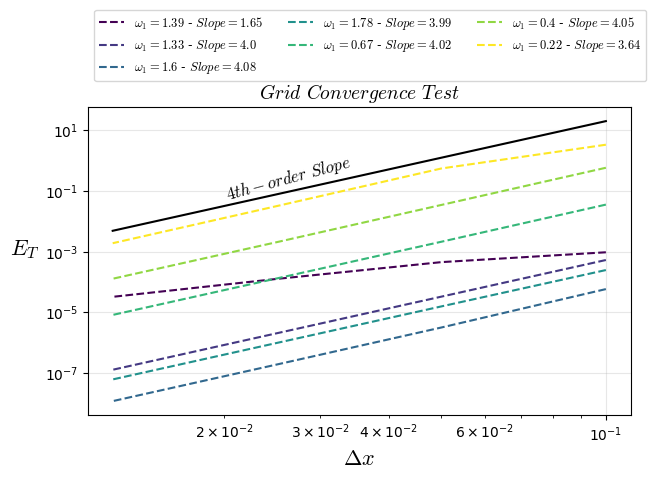

In [27]:
matplotlib.rcParams['mathtext.fontset'] = 'cm'
plt.figure(figsize=(7,4))
plt.title("$Grid$ $Convergence$ $Test$",fontsize=14)
colors = plt.cm.viridis(np.linspace(0, 1, ntests))
# plt.loglog(1/Nx0,ltests[0][3:],'r--',fillstyle='none', label=f'$\\omega={ltests[0][0]}$ - $Slope={ltests[0][2]}$')
for i in range(7):
    plt.loglog(1/Nx0,ltests[i][3:],'--',color=colors[i],fillstyle='none', label=f'$\\omega_{1}={ltests[i][0]}$ - $Slope={ltests[i][2]}$')
    
plt.loglog(1/Nx0,1.*200000.0/(Nx0**4),'k-',fillstyle='none')
plt.text(0.02, 0.05, "$4th-order$ $Slope$", rotation=15,fontsize=12)
# plt.ylim(0,0.01)
plt.grid(True, alpha=0.3)
# plt.legend(loc=2,ncol=3,fontsize=8.5)
plt.legend(ncol=3,fontsize=9,loc="center left",bbox_to_anchor=(0.0, 1.2))
plt.ylabel('$E_{T}$',fontsize=16,rotation=0,horizontalalignment='right')
plt.xlabel('$\Delta x$',fontsize=16)
plt.show()